C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\3552523230.py:25: DtypeWarning: Columns (5,7,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("anemia_full_merged5.csv")


Target Mapping: {'Anemic': np.int64(0), 'Not Anemic': np.int64(1)}
anemia_binary
0    131322
1     41685
Name: count, dtype: int64


C:\Users\Andualem\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params for Logistic Regression: {'solver': 'liblinear', 'C': 1}


C:\Users\Andualem\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params for Random Forest: {'n_estimators': 500, 'max_depth': None}
Best params for XGBoost: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1}
[LightGBM] [Info] Number of positive: 33348, number of negative: 105057
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 820
[LightGBM] [Info] Number of data points in the train set: 138405, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240945 -> initscore=-1.147505
[LightGBM] [Info] Start training from score -1.147505
Best params for LightGBM: {'num_leaves': 127, 'n_estimators': 500, 'learning_rate': 0.05}
[LightGBM] [Info] Number of positive: 33348, number of negative: 105057
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008008 seconds.
You can set `forc

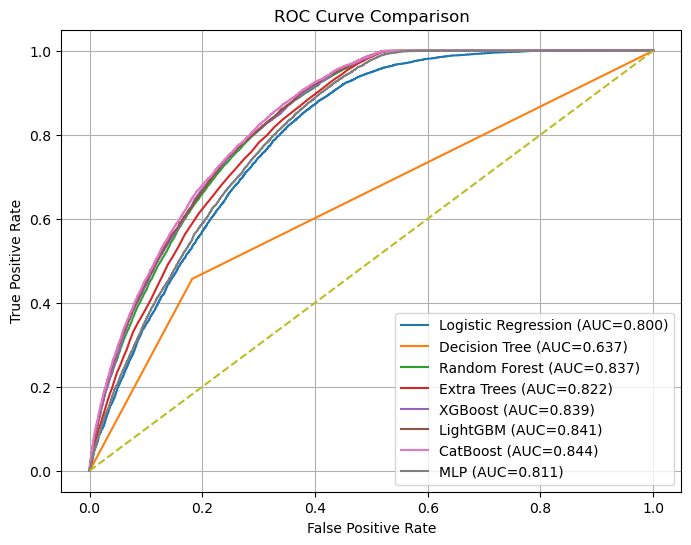

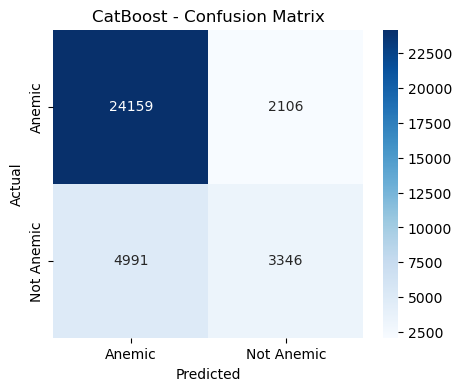


SHAP Analysis for CatBoost


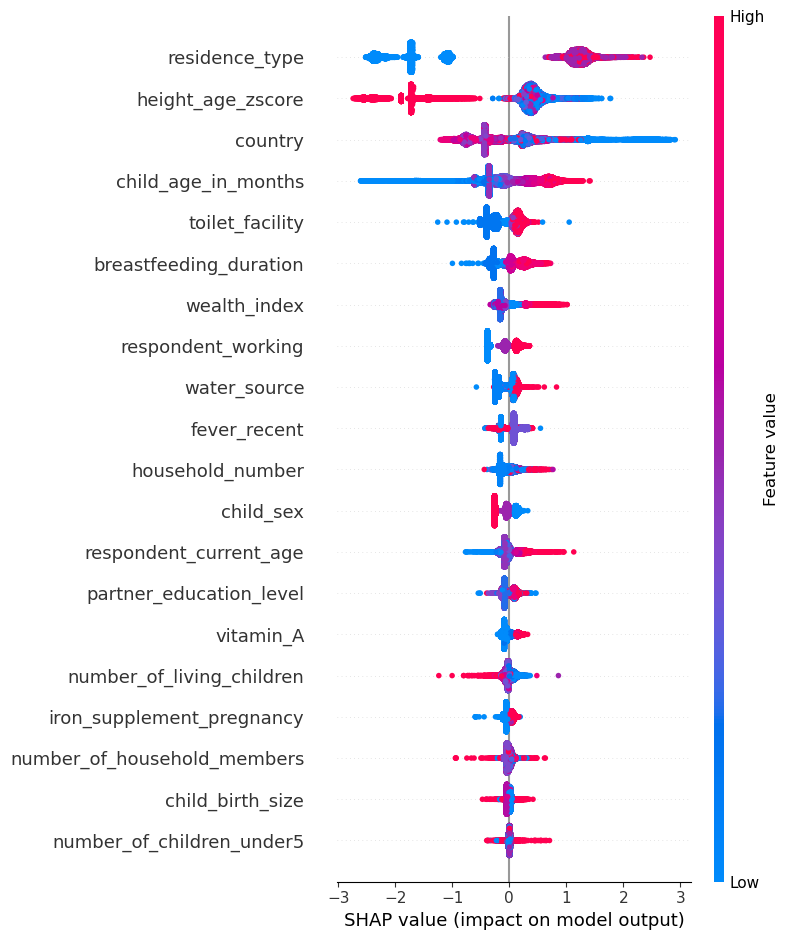

C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\3552523230.py:221: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Angola' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  decoded_sample[col] = le.inverse_transform([int(decoded_sample[col])])[0]


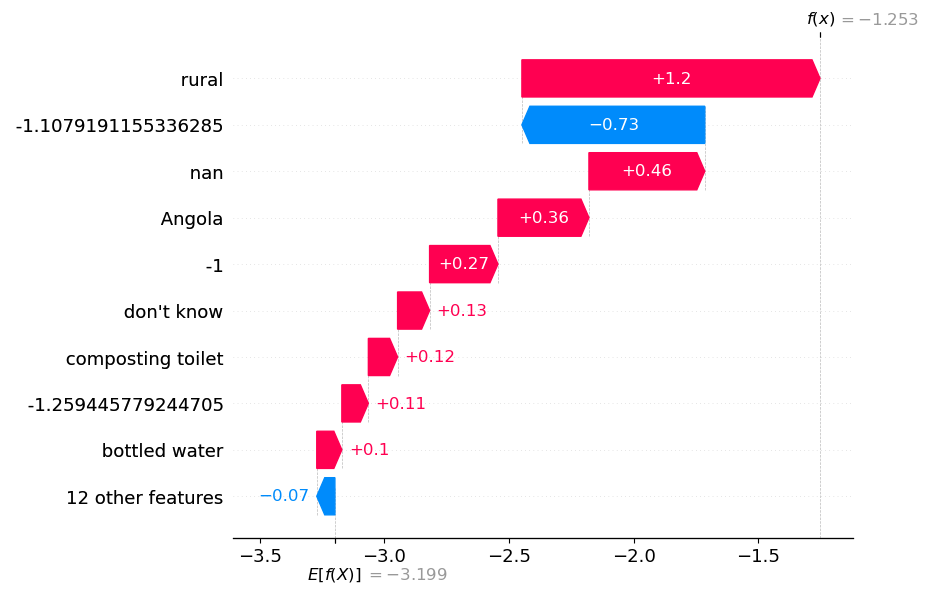

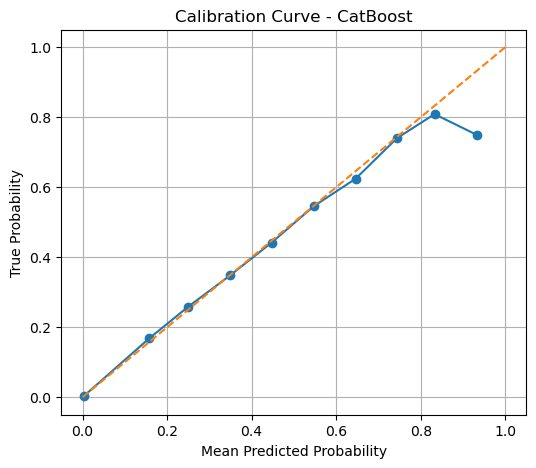

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             accuracy_score, precision_score, recall_score,
                             f1_score, make_scorer)
from sklearn.calibration import calibration_curve

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ---------------------------
# 1. Load Data
# ---------------------------
df = pd.read_csv("anemia_full_merged5.csv")

# ---------------------------
# 2. Target Creation
# ---------------------------
df['anemia_binary'] = df['anemia_level'].apply(
    lambda x: "Not Anemic" if str(x).lower().strip() in
    ["not anemic","none","no","no anemia","not_anemic"]
    else "Anemic"
)

# Encode target
le_target = LabelEncoder()
df['anemia_binary'] = le_target.fit_transform(df['anemia_binary'])

print("Target Mapping:", dict(zip(le_target.classes_,
                                  le_target.transform(le_target.classes_))))
print(df['anemia_binary'].value_counts())

# ---------------------------
# 3. Encode Categorical Features (store encoders)
# ---------------------------
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in ['anemia_level','anemia_binary']:
    if col in categorical_cols:
        categorical_cols.remove(col)

label_encoders = {}

for col in categorical_cols:
    df[col] = df[col].astype(str).fillna("missing")
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ---------------------------
# 4. Define X and y
# ---------------------------
X = df.drop(['anemia_level','anemia_binary'], axis=1, errors='ignore')
y = df['anemia_binary']

# Handle numeric missing + scaling
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 5. Models + Param Grids
# ---------------------------
param_grids = {
    "Logistic Regression": {
        "C":[0.01,0.1,1,10],
        "solver":["lbfgs","liblinear"]
    },
    "Random Forest":{
        "n_estimators":[200,500],
        "max_depth":[5,10,20,None]
    },
    "XGBoost":{
        "n_estimators":[200,500],
        "max_depth":[3,6,10],
        "learning_rate":[0.01,0.05,0.1]
    },
    "LightGBM":{
        "n_estimators":[200,500],
        "num_leaves":[31,63,127],
        "learning_rate":[0.01,0.05,0.1]
    }
}

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

# ---------------------------
# 6. Hyperparameter Tuning
# ---------------------------
def tune_model(name, model):
    if name not in param_grids:
        return model
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        model,
        param_distributions=param_grids[name],
        n_iter=10,
        scoring=make_scorer(f1_score),
        cv=cv,
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train, y_train)
    print(f"Best params for {name}: {search.best_params_}")
    return search.best_estimator_

# ---------------------------
# 7. Train & Evaluate
# ---------------------------
results = []
roc_curves = {}
fitted_models = {}

for name, model in base_models.items():
    model = tune_model(name, model)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model,"predict_proba") else y_pred

    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1":f1_score(y_test,y_pred),
        "ROC-AUC":roc_auc_score(y_test,y_proba)
    })

    if hasattr(model,"predict_proba"):
        fpr,tpr,_ = roc_curve(y_test,y_proba)
        roc_curves[name] = (fpr,tpr,roc_auc_score(y_test,y_proba))

    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("ROC-AUC",ascending=False)
print("\nModel Comparison:")
print(results_df)

# ---------------------------
# 8. ROC Curve (All Models)
# ---------------------------
plt.figure(figsize=(8,6))
for name,(fpr,tpr,auc) in roc_curves.items():
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 9. Confusion Matrix (Best Model)
# ---------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test,y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------
# 10. SHAP Interpretation
# ---------------------------
print(f"\nSHAP Analysis for {best_model_name}")

if best_model_name in ["Random Forest","Extra Trees","XGBoost","LightGBM","CatBoost"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values,list):
        shap_values = shap_values[1]
else:
    explainer = shap.Explainer(best_model,X_train)
    shap_values = explainer(X_test)

# Beeswarm
shap.summary_plot(shap_values,X_test)

# Decode first sample
decoded_sample = X_test.iloc[0].copy()
for col,le in label_encoders.items():
    if col in decoded_sample.index:
        decoded_sample[col] = le.inverse_transform([int(decoded_sample[col])])[0]
decoded_sample = decoded_sample.astype(str)

# Waterfall
feature_names_decoded = [
    f"{col} = {decoded_sample[col]}" for col in X_test.columns
]

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names_decoded
)

# ---------------------------
# 11. Calibration Curve
# ---------------------------
if hasattr(best_model,"predict_proba"):
    y_proba_best = best_model.predict_proba(X_test)[:,1]
    prob_true, prob_pred = calibration_curve(y_test,y_proba_best,n_bins=10)

    plt.figure(figsize=(6,5))
    plt.plot(prob_pred,prob_true,marker='o')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("True Probability")
    plt.title(f"Calibration Curve - {best_model_name}")
    plt.grid()
    plt.show()


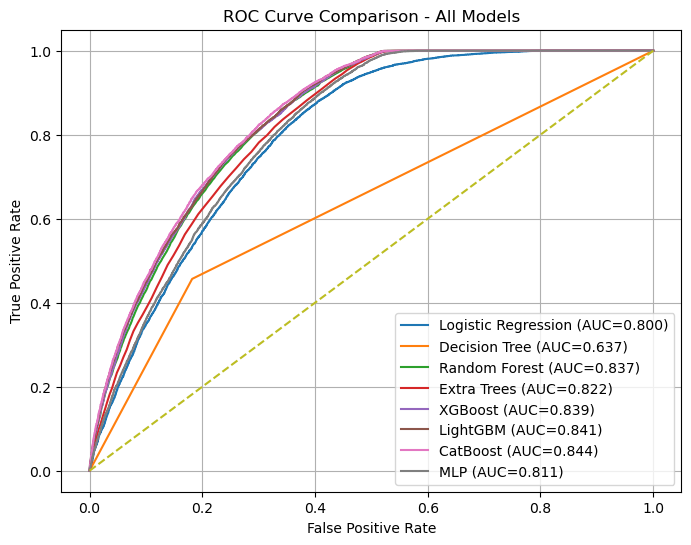

In [2]:
# ---------------------------
# 7. ROC Curve - All Models
# ---------------------------
plt.figure(figsize=(8,6))

for name, (fpr, tpr, auc_score) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")
plt.legend()
plt.grid()
plt.show()



🔎 SHAP Analysis for CatBoost


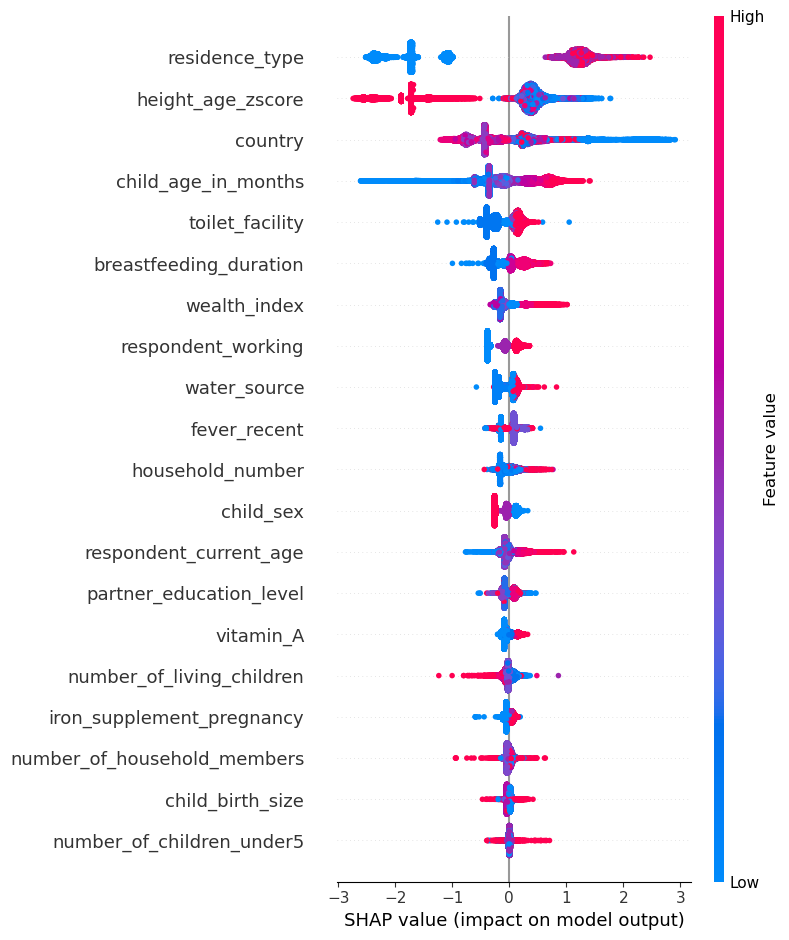

In [3]:
# ---------------------------
# 8. SHAP Interpretation
# ---------------------------
print(f"\n🔎 SHAP Analysis for {best_model_name}")

# Use TreeExplainer for tree-based models
if best_model_name in ["Random Forest", "Extra Trees", "XGBoost", "LightGBM", "CatBoost"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    
    # For binary classification
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

else:
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)

# Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="dot")


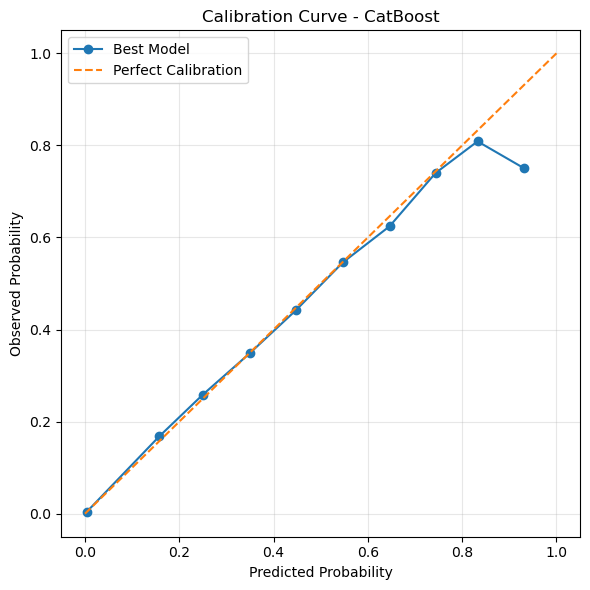

In [5]:
# =========================================
# 📈 Calibration Curve
# =========================================

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Best Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title(f"Calibration Curve - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



SHAP Analysis for CatBoost - Multiple Visualizations
SHAP values type: <class 'numpy.ndarray'>


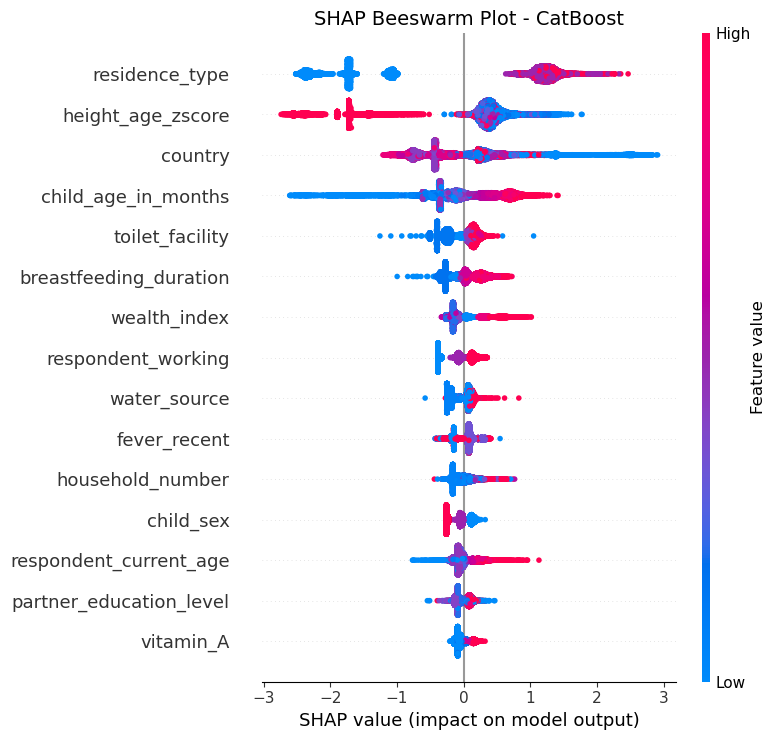

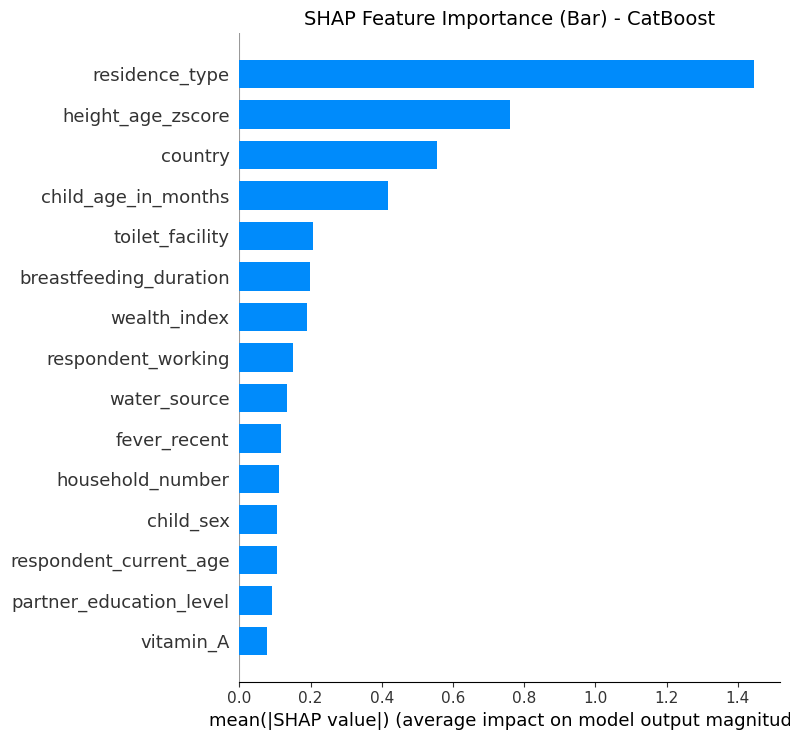

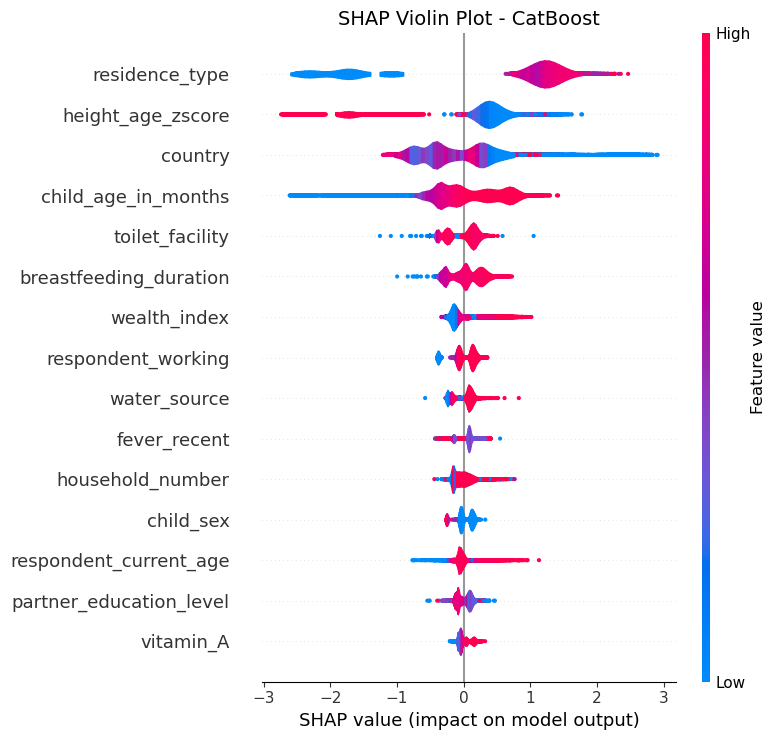

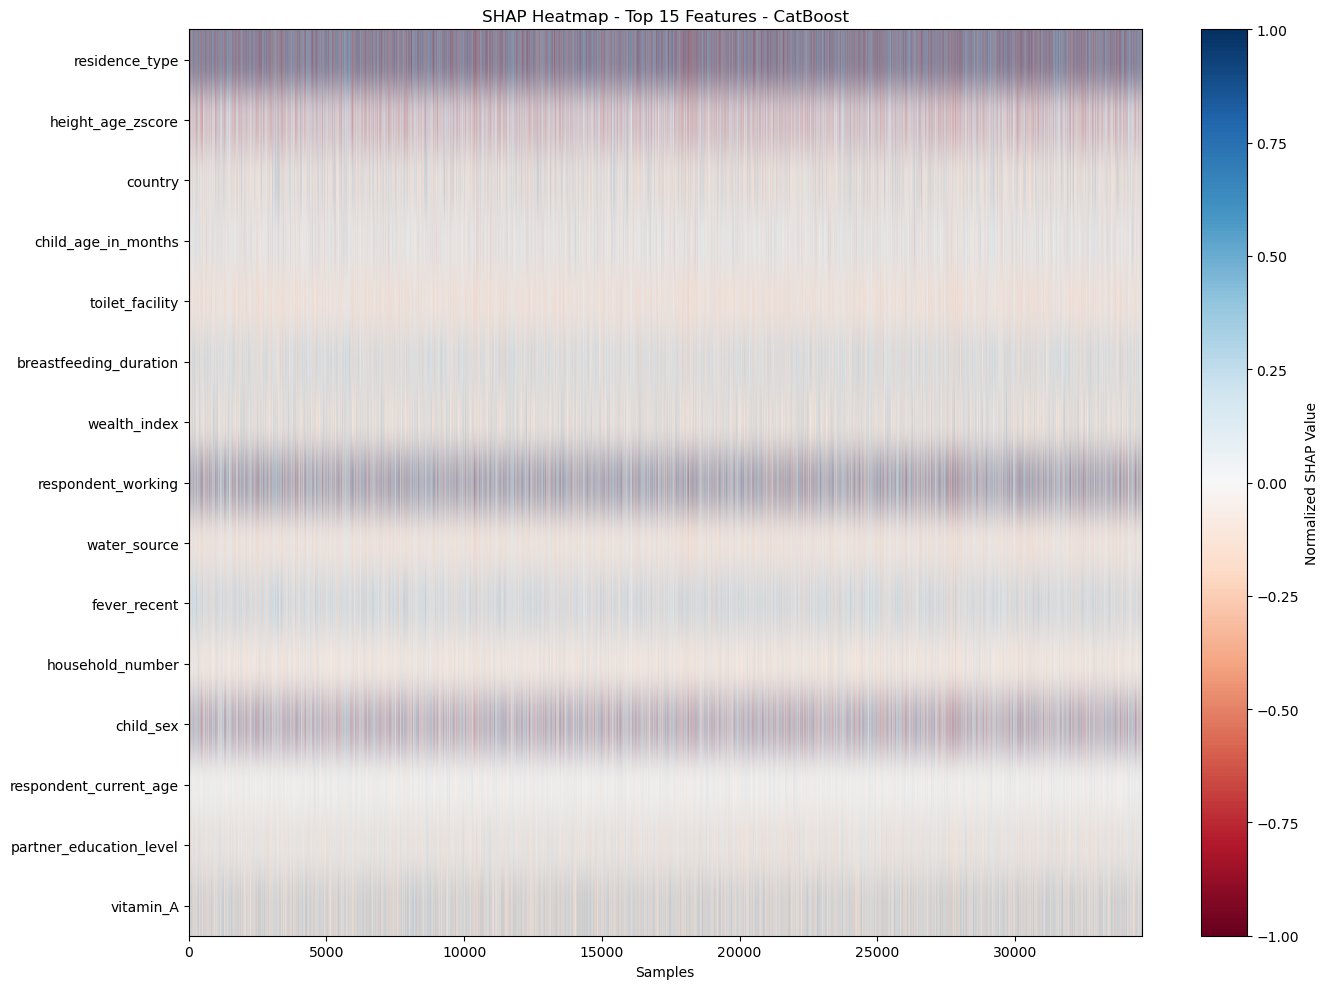

C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Angola' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  decoded_sample[col] = le.inverse_transform([int(decoded_sample[col])])[0]
C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Angola' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  decoded_sample[col] = le.inverse_transform([int(decoded_sample[col])])[0]
C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Angola' has dtype incompatible with float64, please explicit

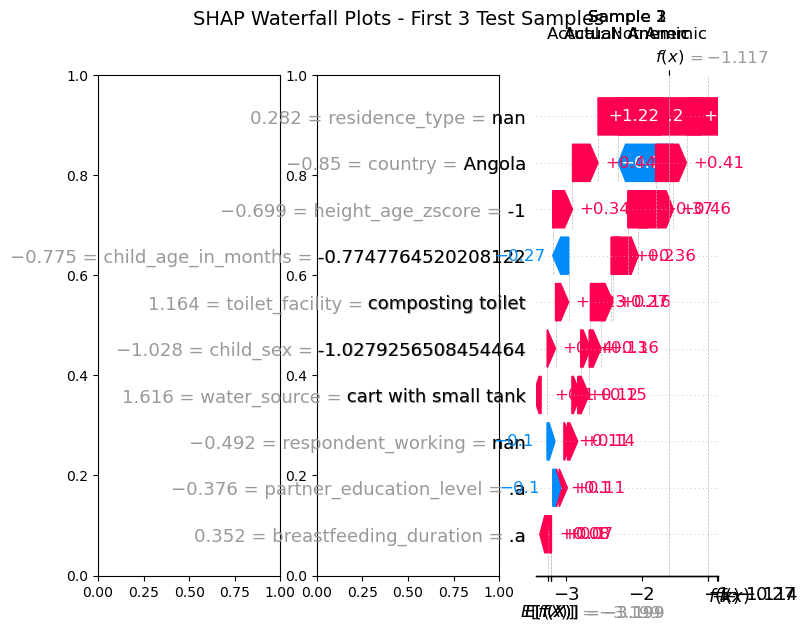


SHAP Dependence Scatter Plots - Top 3 Features


C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(box_data, labels=decoded_labels, patch_artist=True)
C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(box_data, labels=decoded_labels, patch_artist=True)
C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(box_data, labels=decoded_labels, patch_artist=True)


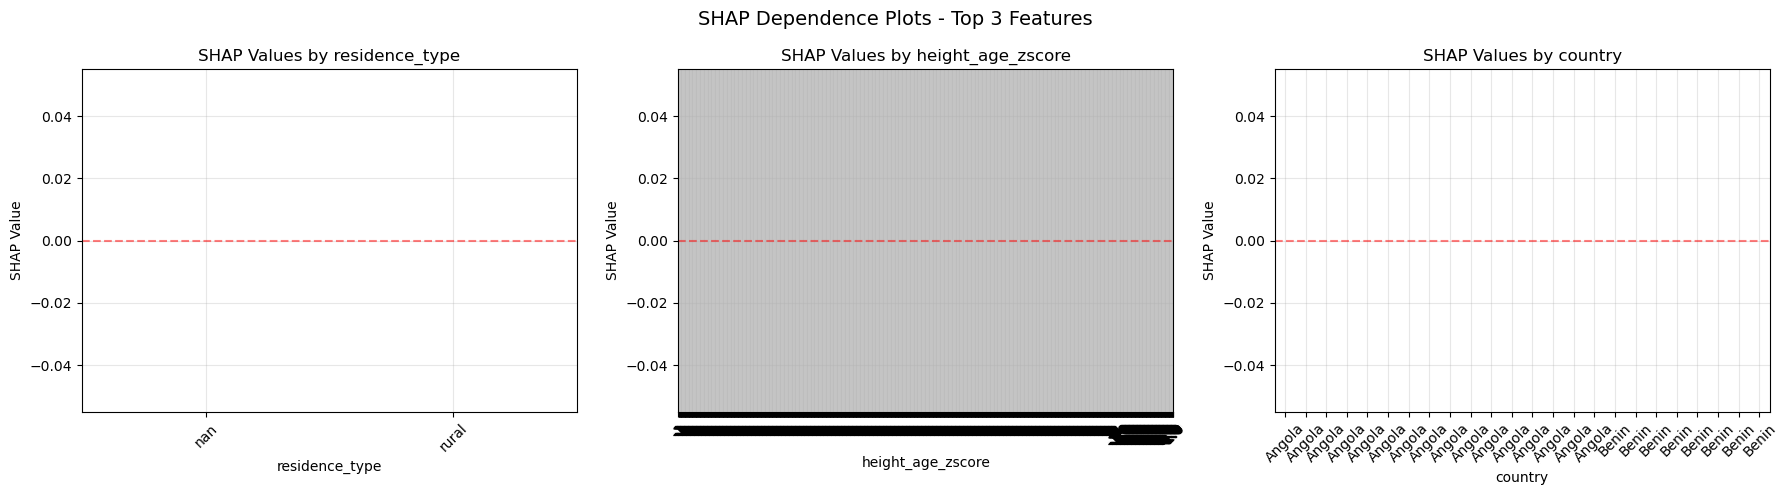


SHAP Force Plot - Multiple Samples


C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:212: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 2000x300 with 0 Axes>

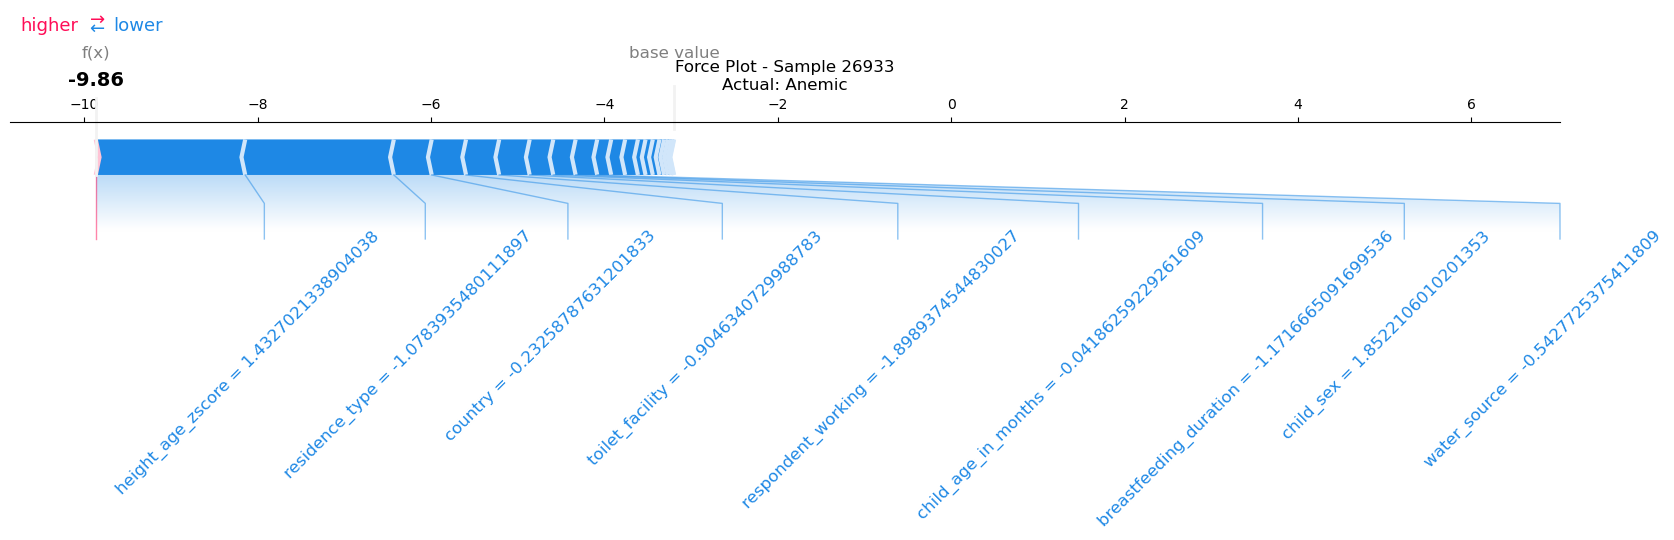

C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:212: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 2000x300 with 0 Axes>

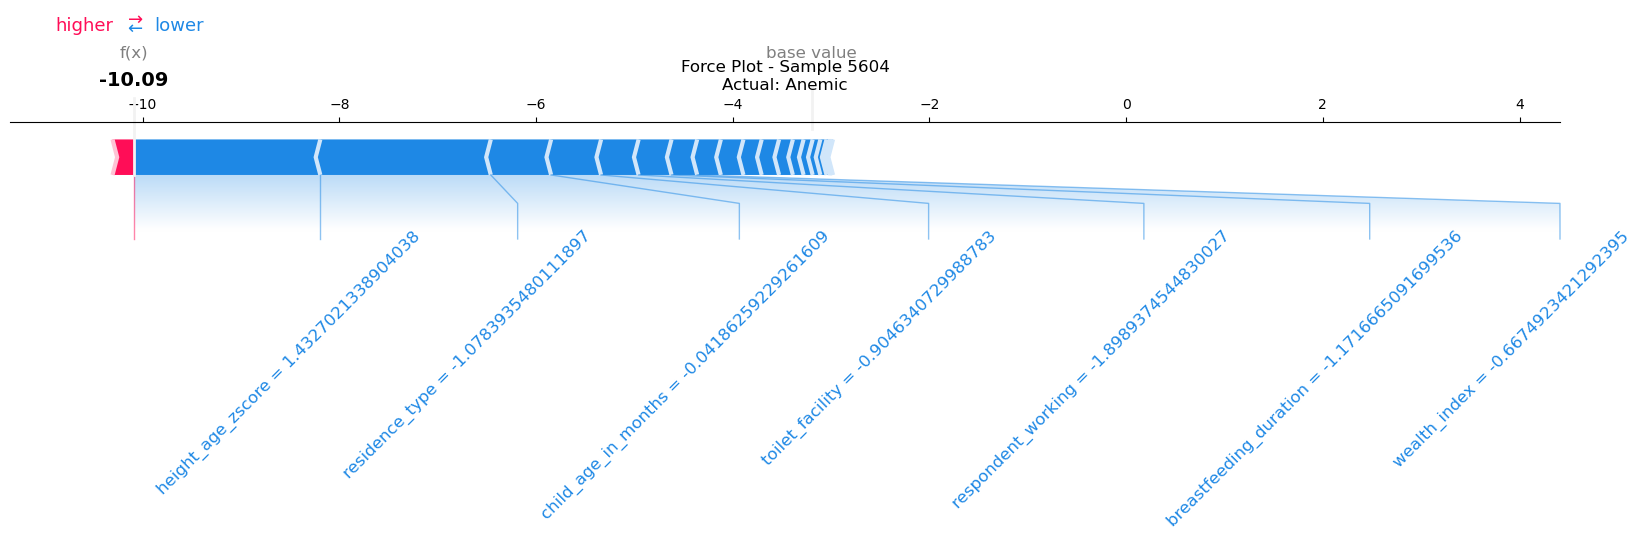

C:\Users\Andualem\AppData\Local\Temp\ipykernel_1924\679807441.py:212: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 2000x300 with 0 Axes>

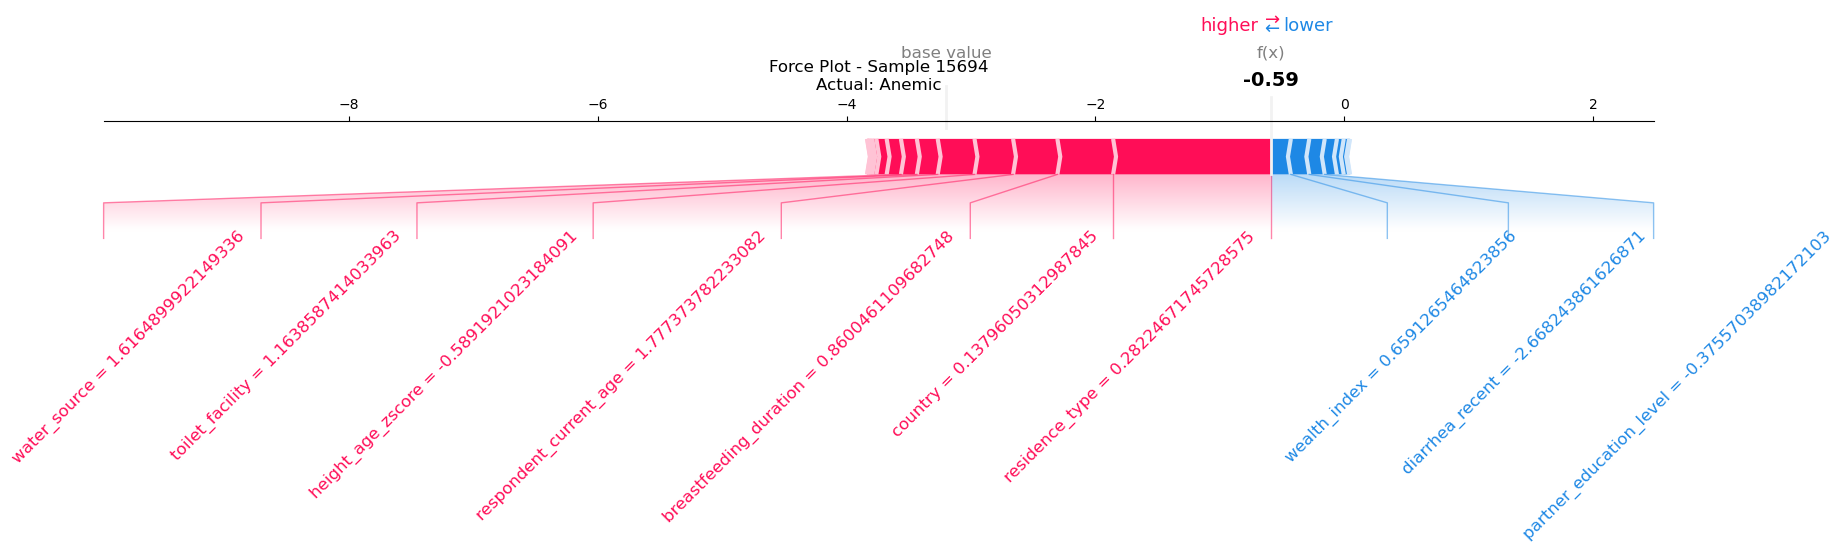


Feature Contribution Matrix


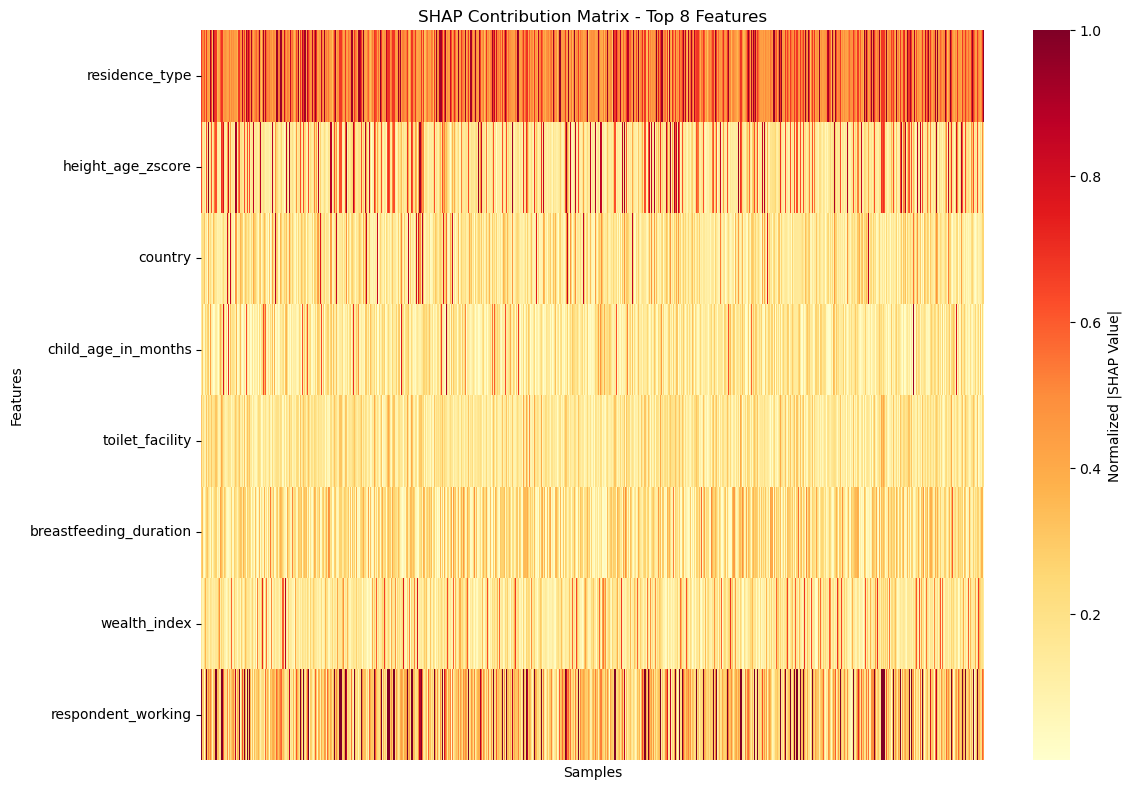


SHAP Interaction Analysis - Top Feature Pairs


In [ ]:
# ---------------------------
# 10. SHAP Interpretation - Multiple Visualization Styles
# ---------------------------
print(f"\nSHAP Analysis for {best_model_name} - Multiple Visualizations")

# Initialize explainer based on model type
if best_model_name in ["Random Forest", "Extra Trees", "XGBoost", "LightGBM", "CatBoost"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    # For tree models, shap_values is numpy array
    shap_type = 'numpy'
else:
    explainer = shap.Explainer(best_model, X_train)
    shap_values_numpy = explainer.shap_values(X_test)
    # Check if shap_values is Explanation object or numpy array
    if hasattr(shap_values_numpy, 'values'):
        shap_values = shap_values_numpy.values
        shap_type = 'explanation'
    else:
        shap_values = shap_values_numpy
        shap_type = 'numpy'

print(f"SHAP values type: {type(shap_values)}")

# Get top features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)
top_3_features = feature_importance.head(3)['feature'].tolist()
top_5_features = feature_importance.head(5)['feature'].tolist()
top_10_features = feature_importance.head(10)['feature'].tolist()

# 1. Standard Beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title(f"SHAP Beeswarm Plot - {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Bar Plot (Global Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
plt.title(f"SHAP Feature Importance (Bar) - {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Violin Plot (Distribution of SHAP values)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="violin", show=False, max_display=15)
plt.title(f"SHAP Violin Plot - {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Heatmap alternative (using matplotlib directly)
plt.figure(figsize=(14, 10))
# Select top 15 features
top_15_indices = [X_test.columns.get_loc(f) for f in feature_importance.head(15)['feature']]
shap_subset = shap_values[:, top_15_indices]

# Normalize for better visualization
shap_norm = shap_subset / np.abs(shap_subset).max(axis=0)

plt.imshow(shap_norm.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Normalized SHAP Value')
plt.yticks(range(len(top_15_indices)), feature_importance.head(15)['feature'].values)
plt.xlabel('Samples')
plt.title(f'SHAP Heatmap - Top 15 Features - {best_model_name}')
plt.tight_layout()
plt.show()

# 5. Waterfall for multiple samples (first 3 test samples)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"SHAP Waterfall Plots - First 3 Test Samples", fontsize=14)

# Get expected value
if hasattr(explainer, 'expected_value'):
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        expected_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        expected_value = explainer.expected_value
else:
    expected_value = 0

for i in range(min(3, len(X_test))):
    # Decode categorical values for this sample
    decoded_sample = X_test.iloc[i].copy()
    for col, le in label_encoders.items():
        if col in decoded_sample.index:
            try:
                decoded_sample[col] = le.inverse_transform([int(decoded_sample[col])])[0]
            except:
                decoded_sample[col] = str(decoded_sample[col])
    
    # Get feature names with values for top features
    feature_names_decoded = []
    top_indices_local = np.argsort(np.abs(shap_values[i]))[-10:]  # Top 10 for this sample
    for idx in top_indices_local:
        col = X_test.columns[idx]
        val = decoded_sample[col]
        feature_names_decoded.append(f"{col} = {val}")
    
    # Create waterfall
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i][top_indices_local],
            base_values=expected_value,
            data=X_test.iloc[i].values[top_indices_local],
            feature_names=feature_names_decoded
        ),
        show=False
    )
    plt.title(f"Sample {i+1}\nActual: {le_target.inverse_transform([y_test.iloc[i]])[0]}")

plt.tight_layout()
plt.show()

# 6. Scatter Plot for Top 3 Features
print("\nSHAP Dependence Scatter Plots - Top 3 Features")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"SHAP Dependence Plots - Top 3 Features", fontsize=14)

for i, feature in enumerate(top_3_features):
    feature_idx = X_test.columns.get_loc(feature)
    
    if feature in label_encoders:
        # For categorical features, create a box plot
        feature_vals = X_test[feature].values
        shap_vals = shap_values[:, feature_idx]
        
        # Decode categories
        unique_vals = np.unique(feature_vals)
        valid_vals = []
        decoded_labels = []
        
        for val in unique_vals:
            try:
                if int(val) in label_encoders[feature].transform(label_encoders[feature].classes_):
                    valid_vals.append(int(val))
                    decoded_labels.append(label_encoders[feature].inverse_transform([int(val)])[0])
            except:
                continue
        
        # Create box plot data
        box_data = [shap_vals[feature_vals == val] for val in valid_vals]
        
        # Box plot
        bp = axes[i].boxplot(box_data, labels=decoded_labels, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('SHAP Value')
        axes[i].set_title(f'SHAP Values by {feature}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[i].grid(True, alpha=0.3)
    else:
        # For numerical features, use scatter
        axes[i].scatter(X_test[feature], shap_values[:, feature_idx], 
                       alpha=0.5, c='blue', s=20)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('SHAP Value')
        axes[i].set_title(f'SHAP Dependence - {feature}')
        axes[i].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[i].grid(True, alpha=0.3)
        
        # Add trend line
        z = np.polyfit(X_test[feature], shap_values[:, feature_idx], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(X_test[feature].min(), X_test[feature].max(), 100)
        axes[i].plot(x_trend, p(x_trend), "r--", alpha=0.8, label='Trend')
        axes[i].legend()

plt.tight_layout()
plt.show()

# 7. Force Plot (using matplotlib)
print("\nSHAP Force Plot - Multiple Samples")
# Select 3 random samples
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), min(3, len(X_test)), replace=False)

for idx in sample_indices:
    plt.figure(figsize=(20, 3))
    
    # Decode feature values for display
    feature_display = {}
    for col in X_test.columns[:10]:  # Show top 10 features
        val = X_test.iloc[idx][col]
        if col in label_encoders:
            try:
                feature_display[col] = label_encoders[col].inverse_transform([int(val)])[0]
            except:
                feature_display[col] = str(val)
        else:
            feature_display[col] = f"{val:.2f}" if isinstance(val, float) else str(val)
    
    # Create force plot
    shap.force_plot(
        expected_value,
        shap_values[idx],
        X_test.iloc[idx],
        matplotlib=True,
        show=False,
        figsize=(20, 3),
        text_rotation=45
    )
    plt.title(f"Force Plot - Sample {idx}\nActual: {le_target.inverse_transform([y_test.iloc[idx]])[0]}")
    plt.tight_layout()
    plt.show()

# 8. Feature Contribution Matrix
print("\nFeature Contribution Matrix")
# Select top 8 features
top_8_features = feature_importance.head(8)['feature'].tolist()
top_8_indices = [X_test.columns.get_loc(f) for f in top_8_features]

# Create contribution matrix
contribution_matrix = np.abs(shap_values)[:, top_8_indices]
contribution_matrix = contribution_matrix / (contribution_matrix.max(axis=0) + 1e-10)  # Normalize

plt.figure(figsize=(12, 8))
sns.heatmap(contribution_matrix.T, 
            cmap='YlOrRd',
            xticklabels=False,
            yticklabels=top_8_features,
            cbar_kws={'label': 'Normalized |SHAP Value|'},
            annot=False)
plt.xlabel('Samples')
plt.ylabel('Features')
plt.title('SHAP Contribution Matrix - Top 8 Features')
plt.tight_layout()
plt.show()

# 9. SHAP Interaction Values (for tree models only)
if best_model_name in ["Random Forest", "Extra Trees", "XGBoost", "LightGBM", "CatBoost"]:
    print("\nSHAP Interaction Analysis - Top Feature Pairs")
    
    try:
        # Calculate interaction values
        shap_interaction = explainer.shap_interaction_values(X_test)
        if isinstance(shap_interaction, list):
            shap_interaction = shap_interaction[1]
        
        # Plot interaction for each top feature
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("SHAP Interaction Effects - Top Features", fontsize=14)
        
        for i, feature in enumerate(top_3_features):
            feature_idx = X_test.columns.get_loc(feature)
            
            # Get main effects and interaction effects
            main_effects = shap_interaction[:, feature_idx, feature_idx]
            interaction_effects = shap_interaction[:, feature_idx, :].sum(axis=1) - main_effects
            
            # Scatter plot
            axes[i].scatter(X_test[feature], main_effects, 
                           alpha=0.5, label='Main Effect', s=20, c='blue')
            axes[i].scatter(X_test[feature], interaction_effects, 
                           alpha=0.5, label='Interaction Effect', s=20, c='red')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('SHAP Value')
            axes[i].set_title(f'Effects for {feature}')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            axes[i].axhline(y=0, color='black', linestyle='--', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not compute interaction values: {e}")

# 10. Decision Plot (using matplotlib)
print("\nSHAP Decision Plot - Multiple Samples")
plt.figure(figsize=(12, 8))

# Select 30 random samples for decision plot
n_samples = min(30, len(X_test))
sample_idx = np.random.choice(len(X_test), n_samples, replace=False)

# Create decision plot manually
shap_subsample = shap_values[sample_idx]
feature_names = X_test.columns.tolist()

# Sort features by importance for display
sorted_idx = np.argsort(np.abs(shap_subsample).mean(axis=0))[::-1]
sorted_features = [feature_names[i] for i in sorted_idx[:10]]  # Top 10

# Calculate cumulative SHAP values
cumulative_shap = np.cumsum(shap_subsample[:, sorted_idx[:10]], axis=1)

# Plot
for i in range(n_samples):
    plt.plot(range(10), cumulative_shap[i] + expected_value, 
             'o-', alpha=0.5, linewidth=1, markersize=3)

plt.xlabel('Features (by importance)')
plt.ylabel('Model output')
plt.title(f'SHAP Decision Plot - {n_samples} Random Samples')
plt.xticks(range(10), sorted_features, rotation=45, ha='right')
plt.axhline(y=expected_value, color='gray', linestyle='--', alpha=0.5, label='Base value')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='Decision threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 11. Summary Statistics Table
print("\n" + "="*70)
print("SHAP SUMMARY STATISTICS - TOP 10 FEATURES")
print("="*70)

# Calculate SHAP statistics
shap_stats = []
for i, feature in enumerate(X_test.columns):
    shap_vals = shap_values[:, i]
    shap_stats.append({
        'Feature': feature,
        'Mean |SHAP|': np.abs(shap_vals).mean(),
        'Std SHAP': shap_vals.std(),
        'Max SHAP': shap_vals.max(),
        'Min SHAP': shap_vals.min(),
        '% Positive': (shap_vals > 0).mean() * 100,
        '% Negative': (shap_vals < 0).mean() * 100
    })

shap_stats_df = pd.DataFrame(shap_stats)
shap_stats_df = shap_stats_df.sort_values('Mean |SHAP|', ascending=False).head(10)
print(shap_stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n" + "="*70)
print("INTERPRETATION GUIDE:")
print("• Mean |SHAP|: Average impact on prediction (higher = more important)")
print("• % Positive/% Negative: Direction of impact on prediction")
print("• Features with high Std SHAP have varying impact across samples")
print("• Positive SHAP = increases probability of Anemic")
print("• Negative SHAP = decreases probability of Anemic (increases Not Anemic)")
print("="*70)

# 12. Feature Importance Bar Chart with Error Bars
plt.figure(figsize=(12, 6))
top_10_features = feature_importance.head(10)['feature'].values
top_10_importance = feature_importance.head(10)['importance'].values

# Bootstrap for error bars
n_bootstrap = 100
bootstrap_means = []
for i in range(n_bootstrap):
    bootstrap_idx = np.random.choice(len(shap_values), len(shap_values), replace=True)
    bootstrap_importance = np.abs(shap_values[bootstrap_idx]).mean(axis=0)
    bootstrap_means.append(bootstrap_importance)

bootstrap_means = np.array(bootstrap_means)
top_10_indices = [X_test.columns.get_loc(f) for f in top_10_features]
bootstrap_errors = bootstrap_means[:, top_10_indices].std(axis=0)

y_pos = np.arange(len(top_10_features))
plt.barh(y_pos, top_10_importance, xerr=bootstrap_errors, 
         capsize=5, color='steelblue', alpha=0.8)
plt.yticks(y_pos, top_10_features)
plt.xlabel('Mean |SHAP Value|')
plt.title(f'Feature Importance with Stability - {best_model_name}')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()